In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astroML.linear_model import LinearRegression, PolynomialRegression, BasisFunctionRegression, NadarayaWatson

/Users/romanow/miniconda3/envs/euclid/lib/python3.13/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


In [2]:
import matplotlib
font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

In [3]:
np.random.seed(123)
X = np.random.random((100, 2)) # 100 points in 2 dimensions
dy = np.random.random(100) # heteroscedastic errors
y = np.random.normal(X[:,0] + X[:,1], dy) # simple plane function

lmodel = LinearRegression()
lmodel.fit(X, y, dy)
y_pred = lmodel.predict(X)

Text(0, 0.5, '$y$')

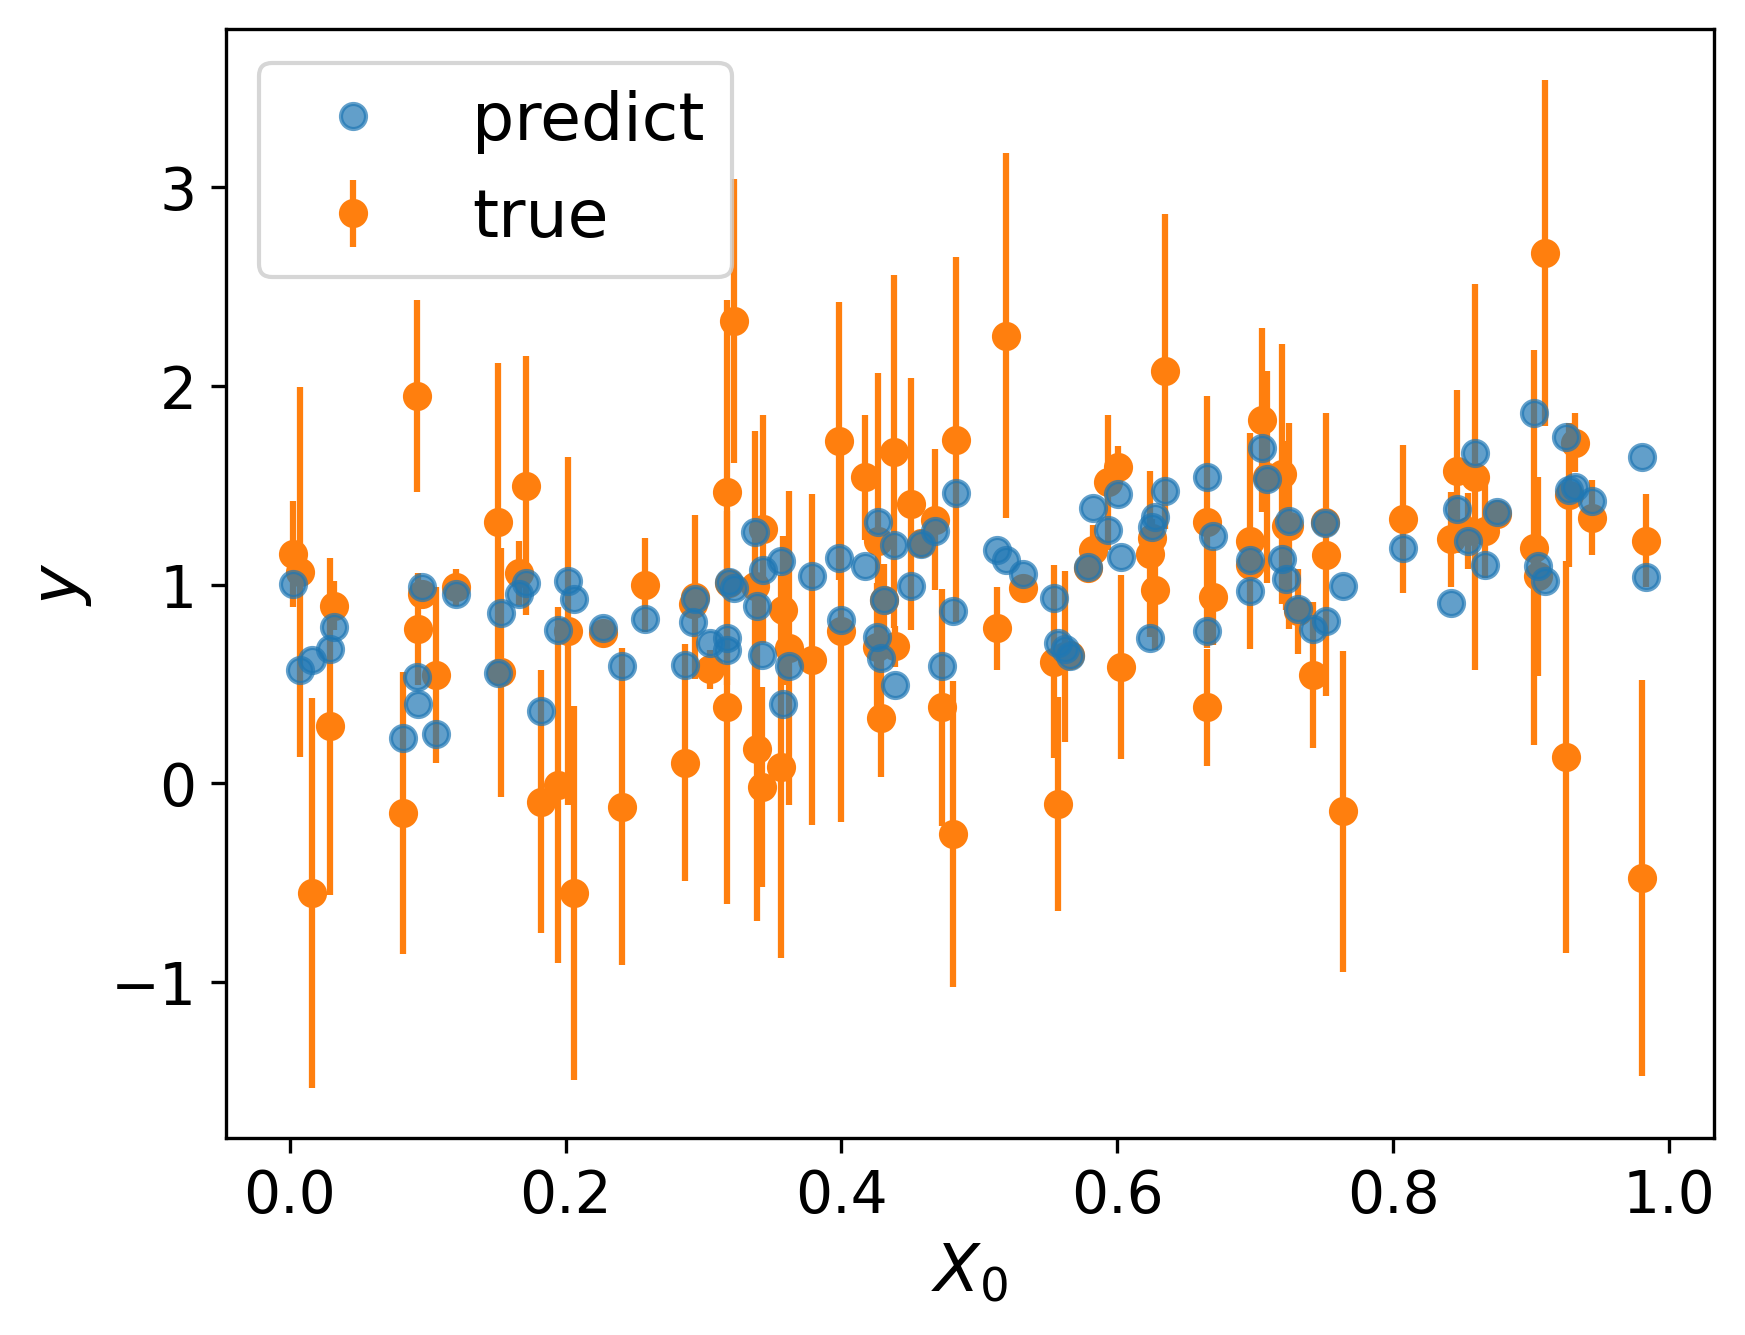

In [4]:
fig1 = plt.figure()
plt.errorbar(X[:,0],y,dy,fmt='o',label='true',c='C1',zorder=1)
#plt.plot(X[:,1],y,'o')
plt.plot(X[:,0],y_pred,'o',label='predict',alpha=0.7,c='C0',zorder=2)
plt.legend(loc='best')
plt.xlabel('$X_0$')
plt.ylabel('$y$')

Now polynomial modeling.

In [5]:
X2 = np.random.random((100, 1)) # 100 points in 1 dimension
dy2 = np.random.random(100) # heteroscedastic errors
y2 = np.random.normal(X2[:,0]**3, dy2) # simple plane function

pmodel = PolynomialRegression(3) # fit 3rd degree polynomial
pmodel.fit(X2, y2, dy2)
y_pred2 = pmodel.predict(X2)

Text(0, 0.5, '$y$')

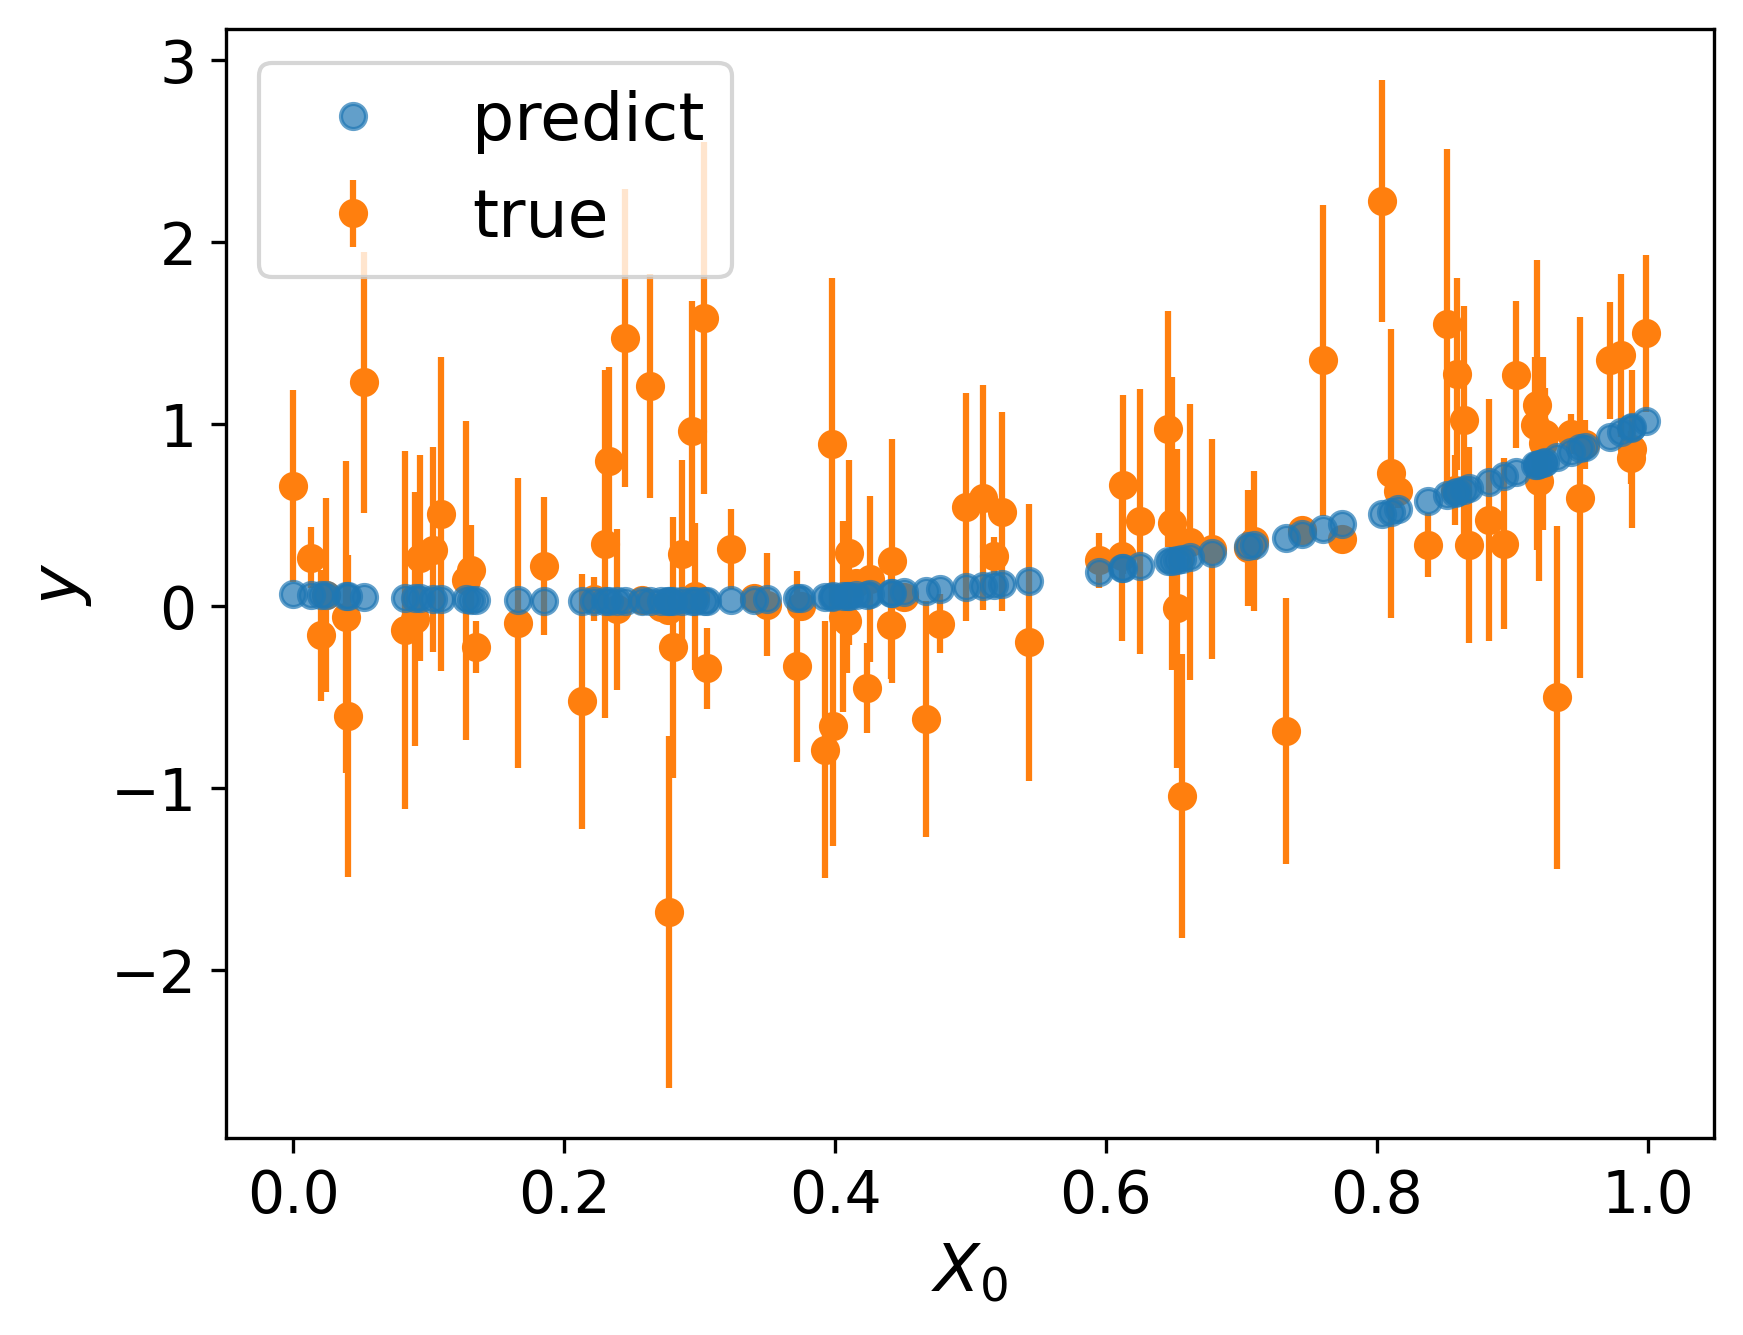

In [6]:
fig2 = plt.figure()
plt.errorbar(X2[:,0],y2,dy2,fmt='o',label='true',c='C1',zorder=1)
plt.plot(X2[:,0],y_pred2,'o',label='predict',alpha=0.7,c='C0',zorder=2)
plt.legend(loc='upper left')
plt.xlabel('$X_0$')
plt.ylabel('$y$')

Now Gaussian basis function regression

In [7]:
X3 = np.random.random((100,1)) # 100 points in 1 dimension
dy3 = 0.4 * np.random.random(100) # heteroscedastic errors
y3 = np.random.normal(X3[:,0]**3, dy3)
mu = np.linspace(0, 1, 10)[:, np.newaxis] # 10x1 array of mu
sigma = 0.1

gmodel = BasisFunctionRegression('gaussian', mu=mu, sigma=sigma)
gmodel.fit(X3, y3, dy3)
y_pred3 = gmodel.predict(X3)

Text(0, 0.5, '$y$')

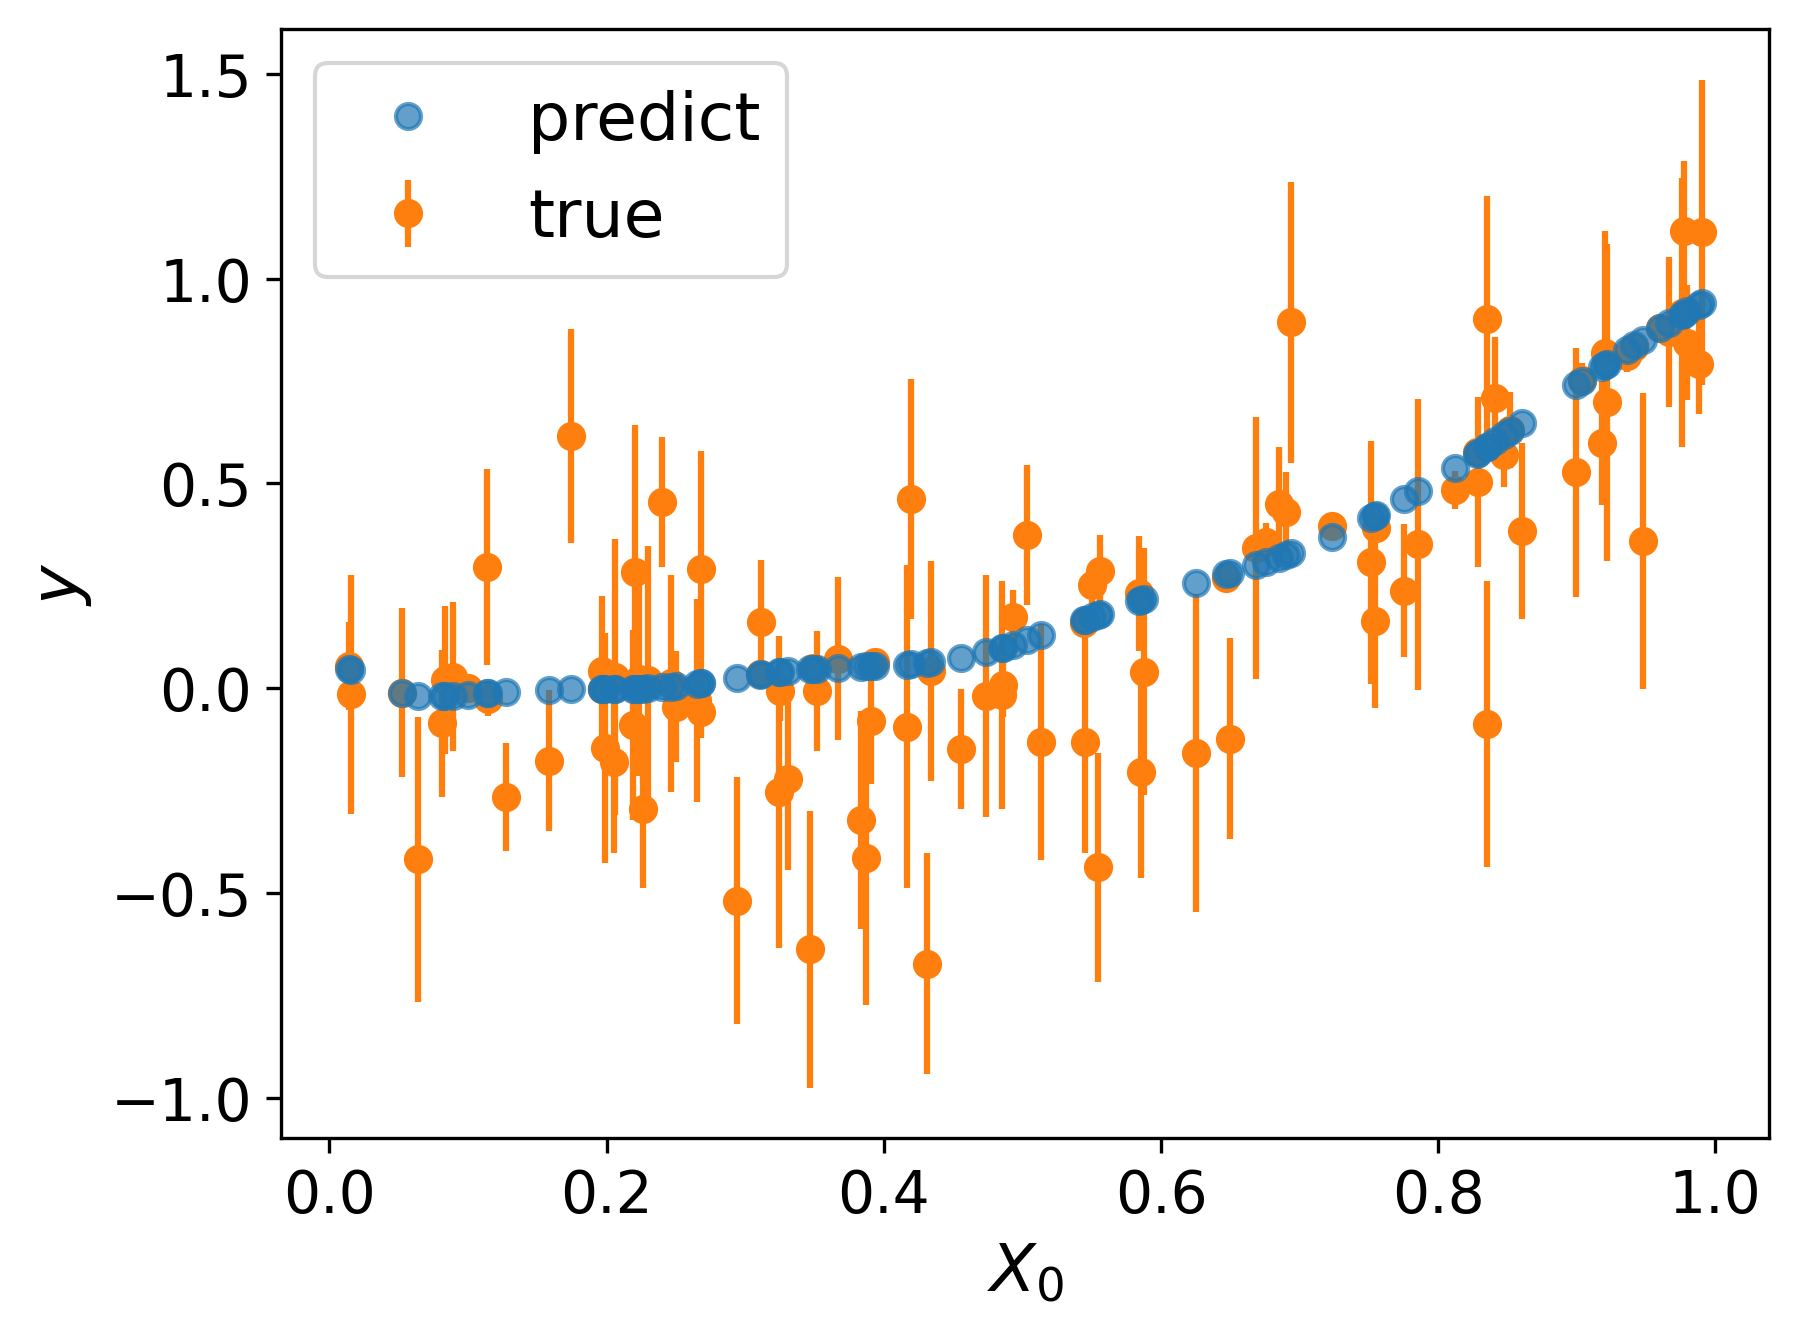

In [8]:
fig3 = plt.figure()
plt.errorbar(X3[:,0],y3,dy3,fmt='o',label='true',c='C1',zorder=1)
plt.plot(X3[:,0],y_pred3,'o',label='predict',alpha=0.7,c='C0',zorder=2)
plt.legend(loc='upper left')
plt.xlabel('$X_0$')
plt.ylabel('$y$')

Gaussian kernel regression provides local smoothing.

In [9]:
X4 = np.random.random((100, 1)) # 100 points in 1 dimension
dy4 = 0.5 * np.random.random(100) # heteroscedastic errors
y4 = np.random.normal(X4[:,0]**3, dy4)

nmodel = NadarayaWatson('gaussian', 0.05) # Gaussian kernel with bandwidth 0.05
nmodel.fit(X4, y4)
y_pred4 = nmodel.predict(X4)

Text(0, 0.5, '$y$')

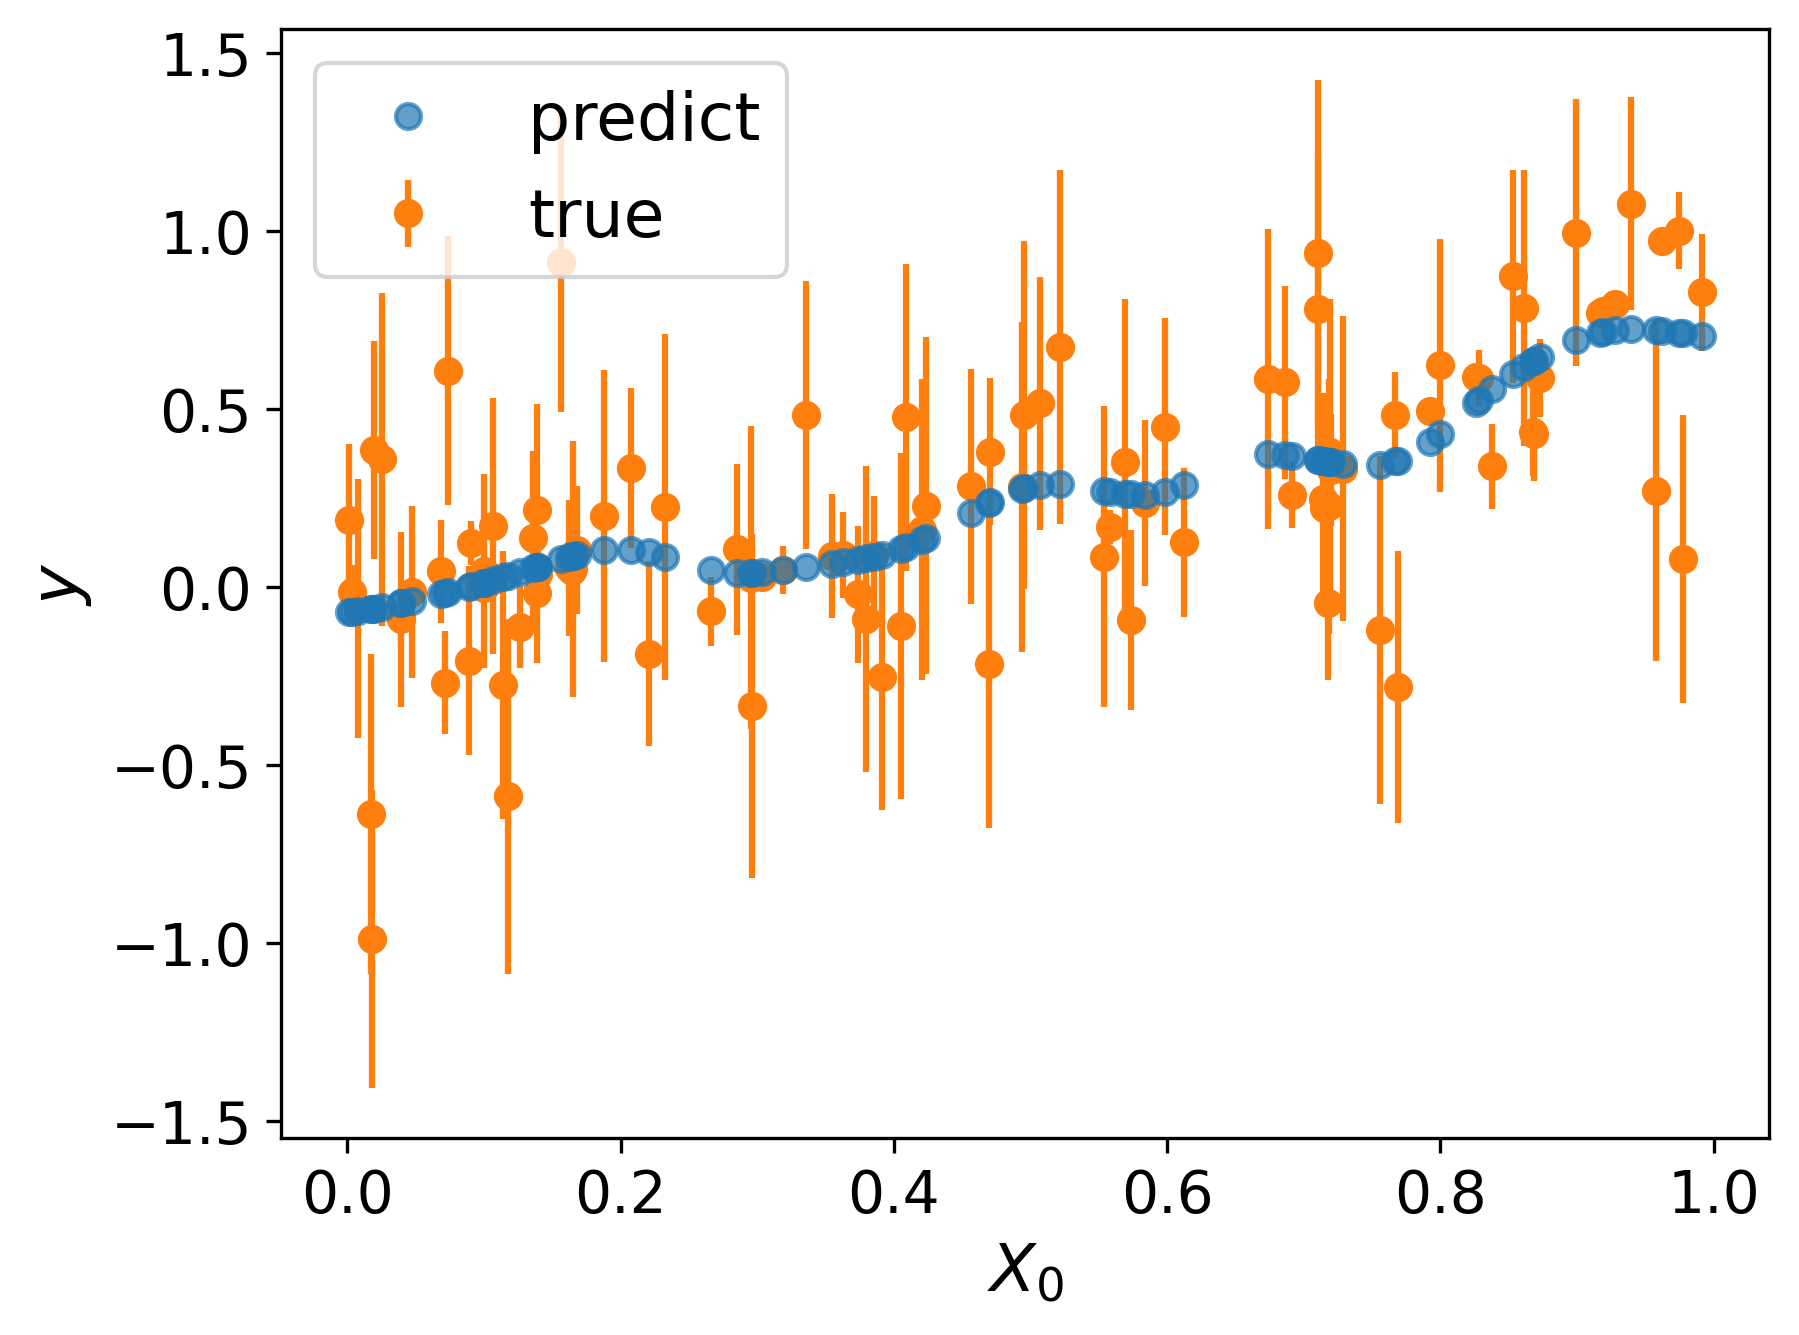

In [10]:
fig4 = plt.figure()
plt.errorbar(X4[:,0],y4,dy4,fmt='o',label='true',c='C1',zorder=1)
plt.plot(X4[:,0],y_pred4,'o',label='predict',alpha=0.7,c='C0',zorder=2)
plt.legend(loc='upper left')
plt.xlabel('$X_0$')
plt.ylabel('$y$')

Now Gaussian process regression, average over infinite set of functions using kernel trick.

In [11]:
import sklearn.gaussian_process as gp

X5 = 10 * np.random.random((25,1)) # 100 points in 1 dimension
dy5 = 0.2 * np.random.random(25) # heteroscedastic errors
y5 = np.random.normal(np.cos(X5[:,0]), dy5) # sample from a cosine curve

kernel1 = gp.kernels.RBF()
gpr = gp.GaussianProcessRegressor(kernel=kernel1, alpha=(dy5 / y5) ** 2) # alpha is to account for noise
gpr.fit(X5, y5)
xmod = np.linspace(0,10,100)
y_pred5, dy_pred5 = gpr.predict(xmod[:,None], return_std=True)
#y_pred5, dy_pred5 = gpr.predict(X5, return_std=True)

Text(0, 0.5, '$y$')

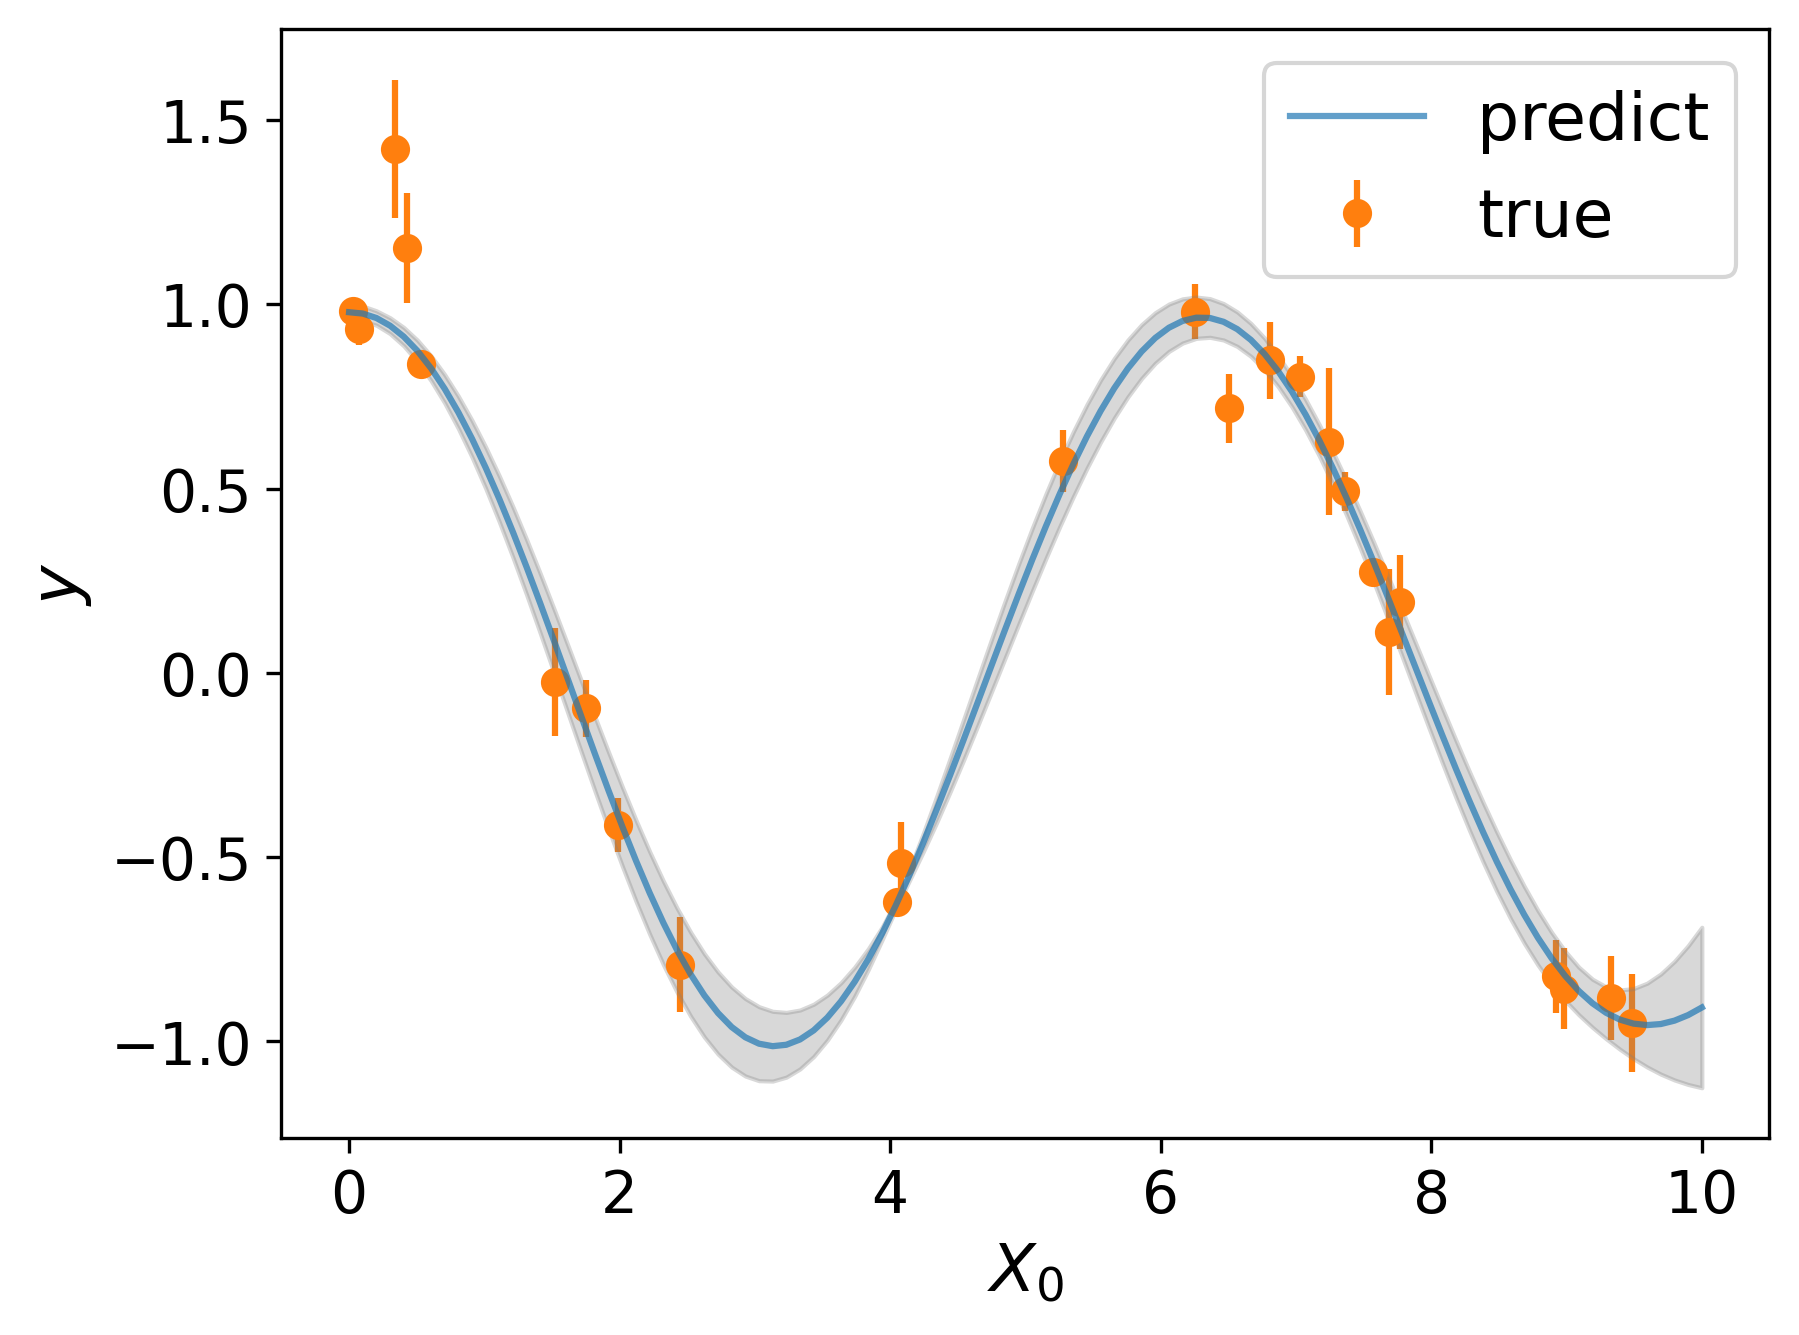

In [12]:
fig5 = plt.figure()
plt.errorbar(X5[:,0],y5,dy5,fmt='o',label='true',c='C1',zorder=1)
#plt.plot(X5[:,0],y_pred5,'o',label='predict',alpha=0.7,c='C0',zorder=2)
plt.plot(xmod,y_pred5,'-',label='predict',alpha=0.7,c='C0',zorder=2)
plt.fill_between(xmod, y_pred5 - dy_pred5, y_pred5 + dy_pred5, color='gray', alpha=0.3)
plt.legend(loc='best')
plt.xlabel('$X_0$')
plt.ylabel('$y$')

Construct learning curve including cross-validation.

In [13]:
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

(-1.0, 0.0)

<Figure size 1920x1440 with 0 Axes>

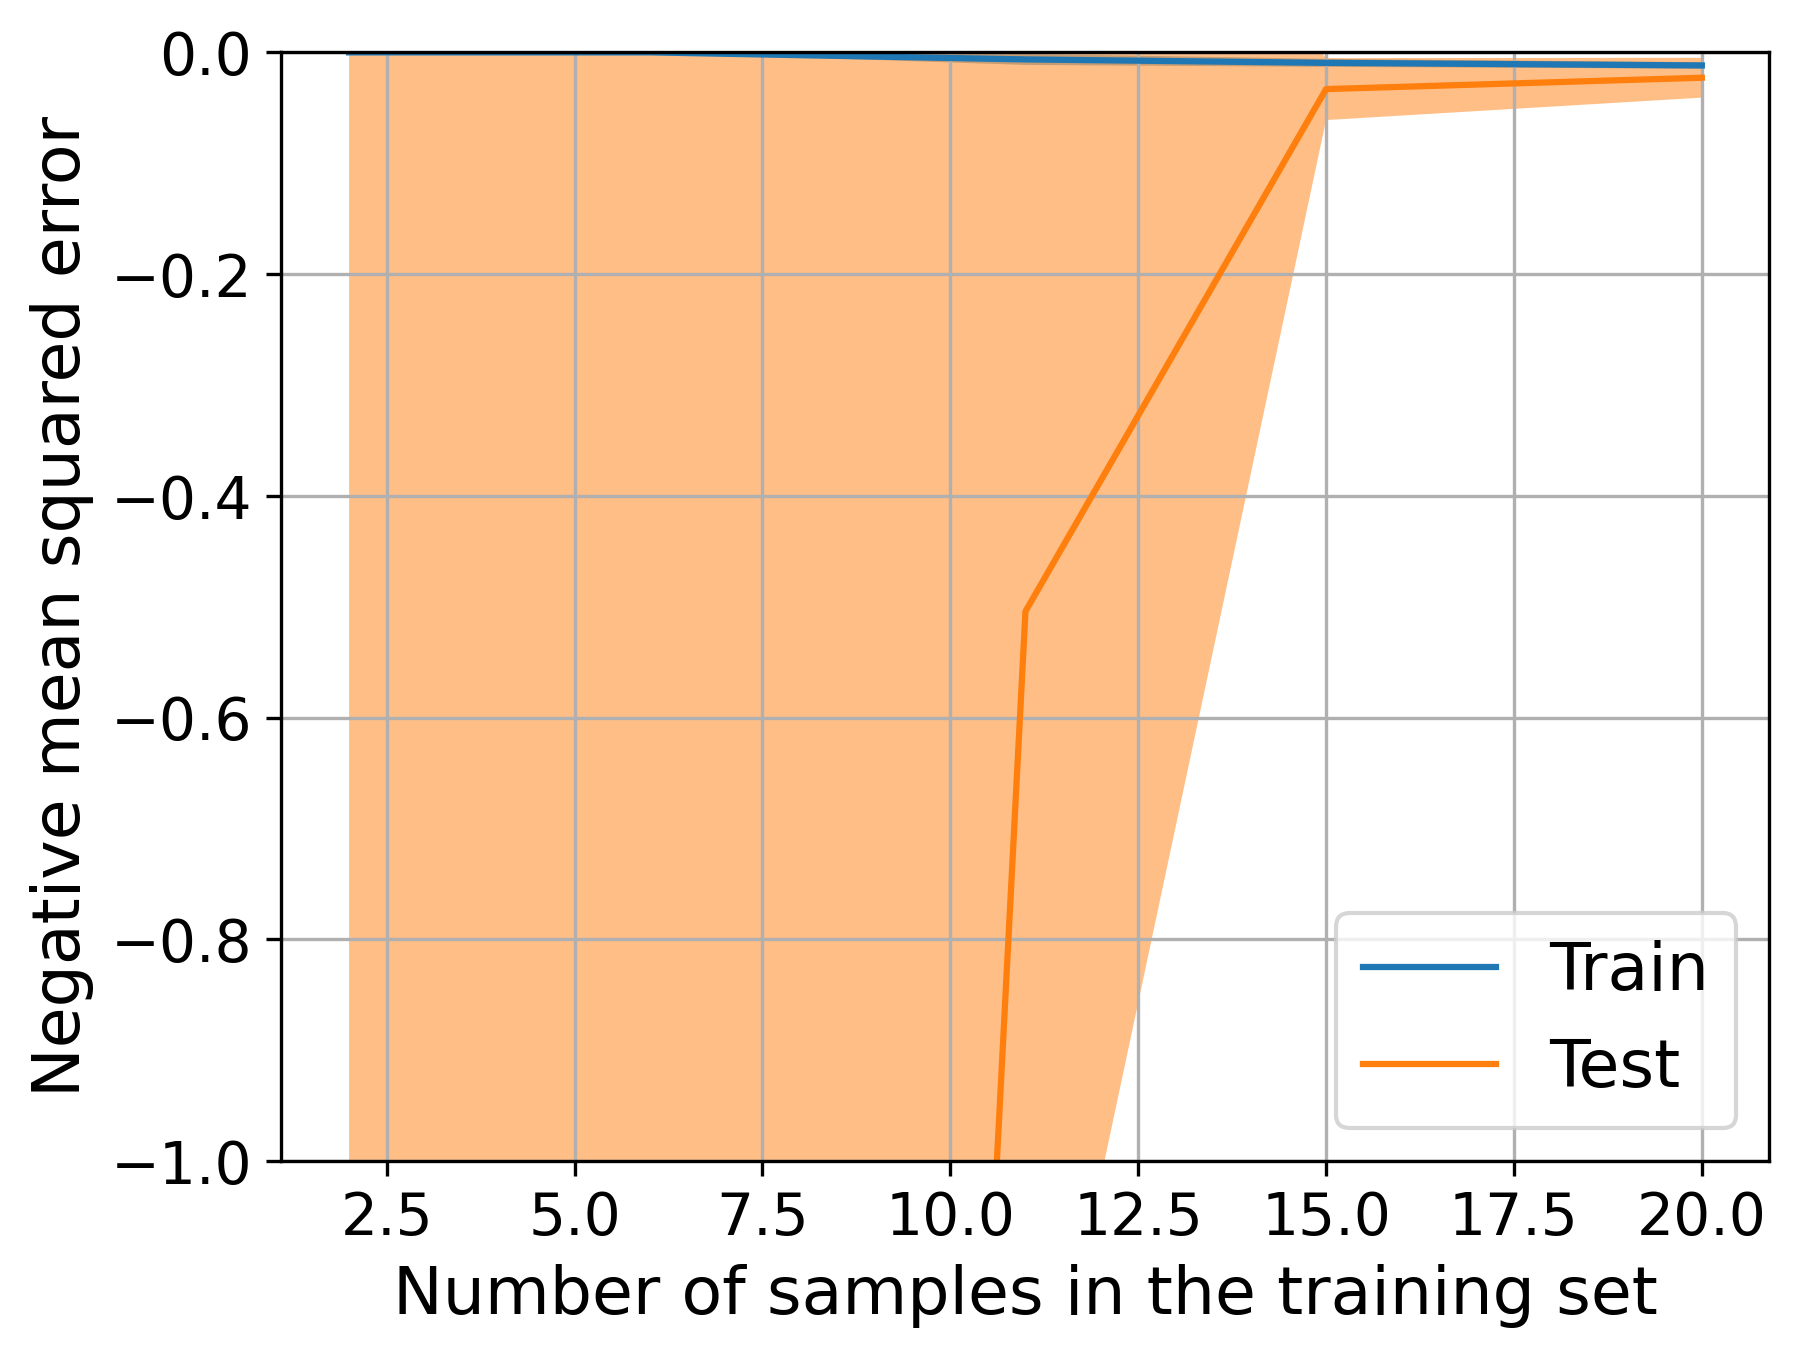

In [18]:
fig6 = plt.figure()
LearningCurveDisplay.from_estimator(PolynomialRegression(5),X5,y5,cv=ShuffleSplit(n_splits=5, test_size=0.2, random_state=0),scoring='neg_mean_squared_error')
plt.grid()
plt.ylim(-1,0)